In [3]:
# This shows us exactly what the column names are
print(df.columns)

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'text'],
      dtype='object')


In [4]:
# We are keeping only 'description' and 'fraudulent'
df = df[['description', 'fraudulent']]

# This shows the first 5 rows of our new, simpler table
df.head()

,description,fraudulent
0,"Food52, a fast-growing, James Beard Award-winn...",0
1,Organised - Focused - Vibrant - Awesome!Do you...,0
2,"Our client, located in Houston, is actively se...",0
3,THE COMPANY: ESRI – Environmental Systems Rese...,0
4,JOB TITLE: Itemization Review ManagerLOCATION:...,0


In [5]:
# Convert the 'description' column to lowercase
df['description'] = df['description'].str.lower()

# Show the first 5 rows to see the change
df.head()

,description,fraudulent
0,"food52, a fast-growing, james beard award-winn...",0
1,organised - focused - vibrant - awesome!do you...,0
2,"our client, located in houston, is actively se...",0
3,the company: esri – environmental systems rese...,0
4,job title: itemization review managerlocation:...,0


In [6]:
import re

# This function keeps only letters and spaces
def clean_special_characters(text):
    # If text is not empty, remove anything that isn't a letter or space
    if isinstance(text, str):
        return re.sub(r'[^a-z\s]', '', text)
    return text

# Apply the function to our description column
df['description'] = df['description'].apply(clean_special_characters)

# Check the first 5 rows again
df.head()

,description,fraudulent
0,food a fastgrowing james beard awardwinning on...,0
1,organised focused vibrant awesomedo you hav...,0
2,our client located in houston is actively seek...,0
3,the company esri environmental systems resear...,0
4,job title itemization review managerlocation f...,0


In [7]:
import nltk
from nltk.corpus import stopwords

# 1. Download the list of stopwords from the internet
nltk.download('stopwords')

# 2. Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# 3. Function to remove stopwords from the text
def remove_stopwords(text):
    if isinstance(text, str):
        # Split text into words, keep only those NOT in stop_words
        words = text.split()
        filtered_words = [word for word in words if word not in stop_words]
        return " ".join(filtered_words)
    return text

# 4. Apply the function
df['description'] = df['description'].apply(remove_stopwords)

# Show the results
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,description,fraudulent
0,food fastgrowing james beard awardwinning onli...,0
1,organised focused vibrant awesomedo passion cu...,0
2,client located houston actively seeking experi...,0
3,company esri environmental systems research in...,0
4,job title itemization review managerlocation f...,0


In [8]:
import sys
!{sys.executable} -m pip install nltk

import nltk
from nltk.corpus import stopwords

# Re-download the list
nltk.download('stopwords')

# Re-run the removal logic
stop_words = set(stopwords.words('english'))
df['description'] = df['description'].apply(lambda x: ' '.join([word for word in str(x).split() if word not in stop_words]))

# Check the results
df.head()


[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,description,fraudulent
0,food fastgrowing james beard awardwinning onli...,0
1,organised focused vibrant awesomedo passion cu...,0
2,client located houston actively seeking experi...,0
3,company esri environmental systems research in...,0
4,job title itemization review managerlocation f...,0


In [9]:
# 1. Download the tool that helps split words
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# 2. Split the description into a list of words
df['tokens'] = df['description'].apply(lambda x: word_tokenize(str(x)))

# 3. View the final result of Phase 3
df[['description', 'tokens']].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,description,tokens
0,food fastgrowing james beard awardwinning onli...,"[food, fastgrowing, james, beard, awardwinning..."
1,organised focused vibrant awesomedo passion cu...,"[organised, focused, vibrant, awesomedo, passi..."
2,client located houston actively seeking experi...,"[client, located, houston, actively, seeking, ..."
3,company esri environmental systems research in...,"[company, esri, environmental, systems, resear..."
4,job title itemization review managerlocation f...,"[job, title, itemization, review, managerlocat..."


In [10]:
# Save the cleaned data so you don't have to clean it again
df.to_csv('cleaned_job_ads.csv', index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the Vectorizer
# We will use the top 3000 most important words to keep it fast
tfidf = TfidfVectorizer(max_features=3000)

# 2. Convert the 'description' text into a big table of numbers (Matrix)
X = tfidf.fit_transform(df['description'])

# 3. Get our 'labels' (0 or 1) into a variable called y
y = df['fraudulent']

print("Words have been converted to numbers!")
print("Shape of X:", X.shape)

Words have been converted to numbers!
Shape of X: (17880, 3000)


In [12]:
import sys
# This installs the machine learning library directly into your project
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from sklearn.model_selection import train_test_split

# We split the data: 80% for training, 20% for testing
# random_state=42 ensures we get the same split every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Data split successfully!")
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Data split successfully!
Training set size: 14304
Testing set size: 3576


In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Create the model
model = MultinomialNB()

# 2. Teach the model (Training)
# This is where the computer learns patterns between words and fraud
model.fit(X_train, y_train)

# 3. Ask the model to predict the "Final Exam" (Testing)
predictions = model.predict(X_test)

# 4. Calculate the accuracy score
accuracy = accuracy_score(y_test, predictions)

print(f"Model Training Complete!")
print(f"The Accuracy of your model is: {accuracy * 100:.2f}%")

Model Training Complete!
The Accuracy of your model is: 96.00%


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC # A fast version of SVM for text

# 1. Initialize the models
lr_model = LogisticRegression(max_iter=1000)
svm_model = LinearSVC(dual=False)

# 2. Train Logistic Regression
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

# 3. Train SVM
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_preds)

# 4. Compare all results
print(f"--- Model Comparison ---")
print(f"Naive Bayes Accuracy: {accuracy * 100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%")
print(f"SVM Accuracy: {svm_acc * 100:.2f}%")

--- Model Comparison ---
Naive Bayes Accuracy: 96.00%
Logistic Regression Accuracy: 96.45%
SVM Accuracy: 97.51%


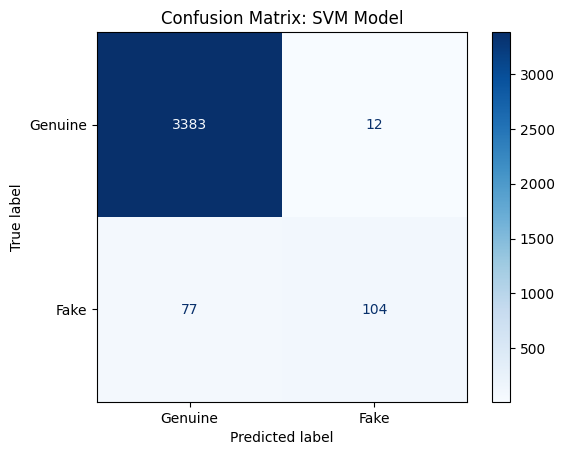

--- Confusion Matrix Values ---
True Negatives (Genuine identified as Genuine): 3383
False Positives (Genuine identified as Fake): 12
False Negatives (Fake identified as Genuine): 77
True Positives (Fake identified as Fake): 104


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Create the confusion matrix for the SVM model
cm = confusion_matrix(y_test, svm_preds)

# 2. Display it visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fake'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: SVM Model')
plt.show()

# 3. Print the text version for your report
print("--- Confusion Matrix Values ---")
print(f"True Negatives (Genuine identified as Genuine): {cm[0][0]}")
print(f"False Positives (Genuine identified as Fake): {cm[0][1]}")
print(f"False Negatives (Fake identified as Genuine): {cm[1][0]}")
print(f"True Positives (Fake identified as Fake): {cm[1][1]}")

In [17]:
import sys
# This installs the library used for creating graphs and charts
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from sklearn.metrics import classification_report

# Generate the report for the best model (SVM)
report = classification_report(y_test, svm_preds, target_names=['Genuine', 'Fake'])
print("--- Final Model Performance (SVM) ---")
print(report)

--- Final Model Performance (SVM) ---
              precision    recall  f1-score   support

     Genuine       0.98      1.00      0.99      3395
        Fake       0.90      0.57      0.70       181

    accuracy                           0.98      3576
   macro avg       0.94      0.79      0.84      3576
weighted avg       0.97      0.98      0.97      3576



In [19]:
import joblib

# 1. Save the trained SVM model
joblib.dump(svm_model, 'svm_job_model.pkl')

# 2. Save the TF-IDF vectorizer (essential to convert new text to numbers)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load data (ensure the file name is correct)
df = pd.read_csv('job_ads.csv.zip')
df.fillna(' ', inplace=True)
df['text'] = df['title'] + " " + df['description'] + " " + df['requirements']

# 2. Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['text'])
y = df['fraudulent']

# 3. Splitting (This creates X_train, y_train, etc.)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Variables Defined: X_train, X_test, y_train, y_test are ready!")

Variables Defined: X_train, X_test, y_train, y_test are ready!


<Figure size 600x600 with 0 Axes>

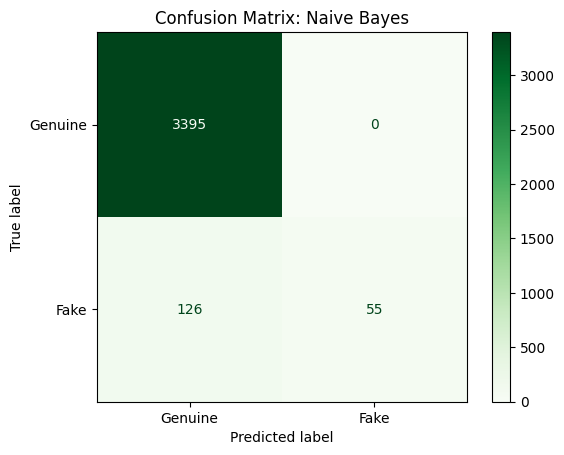

Naive Bayes - True Negatives: 3395, False Positives: 0
Naive Bayes - False Negatives: 126, True Positives: 55


In [21]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize and Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 2. Make Predictions
nb_preds = nb_model.predict(X_test)

# 3. Create and Display Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_preds)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Genuine', 'Fake'])

# Plotting
plt.figure(figsize=(6,6))
disp_nb.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix: Naive Bayes')
plt.show()

# 4. Print values for your report
print(f"Naive Bayes - True Negatives: {cm_nb[0][0]}, False Positives: {cm_nb[0][1]}")
print(f"Naive Bayes - False Negatives: {cm_nb[1][0]}, True Positives: {cm_nb[1][1]}")

<Figure size 600x600 with 0 Axes>

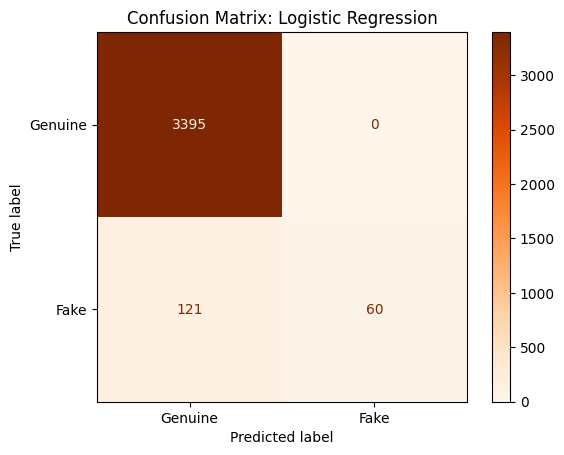

Logistic Regression - True Negatives: 3395, False Positives: 0
Logistic Regression - False Negatives: 121, True Positives: 60


In [22]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize and Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# 2. Make Predictions
lr_preds = lr_model.predict(X_test)

# 3. Create and Display Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Genuine', 'Fake'])

# Plotting
plt.figure(figsize=(6,6))
disp_lr.plot(cmap=plt.cm.Oranges)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

# 4. Print values for your report
print(f"Logistic Regression - True Negatives: {cm_lr[0][0]}, False Positives: {cm_lr[0][1]}")
print(f"Logistic Regression - False Negatives: {cm_lr[1][0]}, True Positives: {cm_lr[1][1]}")

In [23]:
from sklearn.metrics import classification_report

# Generate the report for Naive Bayes
report_nb = classification_report(y_test, nb_preds, target_names=['Genuine', 'Fake'])

print("--- Final Model Performance (Naive Bayes) ---")
print(report_nb)

--- Final Model Performance (Naive Bayes) ---
              precision    recall  f1-score   support

     Genuine       0.96      1.00      0.98      3395
        Fake       1.00      0.30      0.47       181

    accuracy                           0.96      3576
   macro avg       0.98      0.65      0.72      3576
weighted avg       0.97      0.96      0.96      3576



In [24]:
from sklearn.metrics import classification_report

# Generate the report for Logistic Regression
report_lr = classification_report(y_test, lr_preds, target_names=['Genuine', 'Fake'])

print("--- Final Model Performance (Logistic Regression) ---")
print(report_lr)

--- Final Model Performance (Logistic Regression) ---
              precision    recall  f1-score   support

     Genuine       0.97      1.00      0.98      3395
        Fake       1.00      0.33      0.50       181

    accuracy                           0.97      3576
   macro avg       0.98      0.67      0.74      3576
weighted avg       0.97      0.97      0.96      3576



In [25]:
import joblib

# 1. Save the trained Logistic Regression model
joblib.dump(lr_model, 'lr_job_model.pkl')

print("Logistic Regression Model saved successfully!")

Logistic Regression Model saved successfully!


In [26]:
import joblib

# 1. Save the trained Naive Bayes model
joblib.dump(nb_model, 'nb_job_model.pkl')

print("Naive Bayes Model saved successfully!")

Naive Bayes Model saved successfully!


In [27]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Re-create the Vectorizer with 5000 features
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['text'])
y = df['fraudulent']

# 2. Re-split and Re-train ALL models to match 5000 features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Retrain
svm_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# 3. Save EVERYTHING again to your 'models/' folder
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(svm_model, 'svm_job_model.pkl')
joblib.dump(nb_model, 'nb_job_model.pkl')
joblib.dump(lr_model, 'lr_job_model.pkl')

print("Sync Complete: All models and vectorizer now use 5000 features.")

Sync Complete: All models and vectorizer now use 5000 features.
